<a href="https://colab.research.google.com/github/KarolOszek/lol-match-predictor/blob/main/Testing%20different%20models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data Loading & Preprocessing

In [1]:
import pandas as pd

In [2]:
df_al = pd.read_csv('AL_match_history.csv')

In [3]:
df_al = pd.read_csv('AL_match_history.csv')

In [4]:
df_blg = pd.read_csv('BLG_match_history.csv')

In [5]:
df_EDG = pd.read_csv('EDG_match_history.csv')
df_IG = pd.read_csv('IG_match_history.csv')
df_LGD = pd.read_csv('LGD_match_history.csv')
df_LNG = pd.read_csv('LNG_match_history.csv')
df_NIP = pd.read_csv('NIP_match_history.csv')
df_TES = pd.read_csv('TES_match_history.csv')
df_TT = pd.read_csv('TT_match_history.csv')
df_WBG = pd.read_csv('WBG_match_history.csv')
df_WE = pd.read_csv('WE_match_history.csv')

In [6]:
df_all = pd.concat([df_al, df_blg, df_EDG, df_IG, df_LGD, df_LNG, df_NIP, df_TES, df_TT, df_WBG, df_WE],ignore_index=True)

In [7]:
df_all

,AL Result,Score,Side,Kills,Golds,Towers,Dragons,Vs,Kills.1,Golds.1,...,BLG Result,EDG Result,IG Result,LGD Result,LNG Result,NIP Result,TES Result,TT Result,WBG Result,WE Result
0,WIN,2-0,Blue,20,51.5,8,1,TT,8,43.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,WIN,|,Red,15,48.7,9,3,TT,3,37.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,WIN,2-0,Blue,27,61.7,9,2,EDG,11,54.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,WIN,|,Blue,22,58.0,9,2,EDG,6,45.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,WIN,2-0,Blue,29,70.5,10,2,TES,13,60.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,NaN,2-1,Red,15,60.7,8,4,JDG,7,56.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WIN
114,NaN,|,Red,9,53.3,0,2,JDG,20,64.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LOSS
115,NaN,|,Blue,22,67.1,9,2,JDG,13,62.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WIN
116,NaN,0-2,Red,15,52.5,2,1,TES,42,67.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LOSS


after failing to concat right way im starting fixing it

In [8]:
dfs = [df_al, df_blg, df_EDG, df_IG, df_LGD, df_LNG, df_NIP, df_TES, df_TT, df_WBG, df_WE]

In [9]:
dfs_fixed = []

In [10]:
for df in dfs:
  df_temp = df.copy()
  result_col = [col for col in df_temp.columns if 'Result' in col][0]
  team_name = result_col.replace(' Result', '').strip()
  df_temp['Team'] = team_name
  df_temp['Result'] = df_temp[result_col]
  df_temp = df_temp.drop(columns=[result_col])

  dfs_fixed.append(df_temp)

df_all = pd.concat(dfs_fixed, ignore_index=True)

In [11]:
df_all

,Score,Side,Kills,Golds,Towers,Dragons,Vs,Kills.1,Golds.1,Towers.1,Dragons.1,Duration,Game,Patch,Week,Tournament,Team,Result
0,2-0,Blue,20,51.5,8,1,TT,8,43.9,2,1,24:09:00,AL vs TT (2),16.14,WEEK2,LPL 2026 Split 3,AL,WIN
1,|,Red,15,48.7,9,3,TT,3,37.0,1,0,21:55,AL vs TT (1),16.14,WEEK2,LPL 2026 Split 3,AL,WIN
2,2-0,Blue,27,61.7,9,2,EDG,11,54.2,1,2,27:43:00,AL vs EDG (2),16.14,WEEK2,LPL 2026 Split 3,AL,WIN
3,|,Blue,22,58.0,9,2,EDG,6,45.1,2,1,25:05:00,AL vs EDG (1),16.14,WEEK2,LPL 2026 Split 3,AL,WIN
4,2-0,Blue,29,70.5,10,2,TES,13,60.8,2,3,31:23:00,Top Esports vs AL (2),16.14,WEEK2,LPL 2026 Split 3,AL,WIN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,2-1,Red,15,60.7,8,4,JDG,7,56.1,2,0,30:24:00,Team WE vs JD Gaming (3),16.14,WEEK1,LPL 2026 Split 3,WE,WIN
114,|,Red,9,53.3,0,2,JDG,20,64.9,9,2,30:02:00,Team WE vs JD Gaming (2),16.14,WEEK1,LPL 2026 Split 3,WE,LOSS
115,|,Blue,22,67.1,9,2,JDG,13,62.2,4,2,32:00:00,Team WE vs JD Gaming (1),16.14,WEEK1,LPL 2026 Split 3,WE,WIN
116,0-2,Red,15,52.5,2,1,TES,42,67.4,9,3,29:09:00,Top Esports vs Team WE (2),16.13,WEEK1,LPL 2026 Split 3,WE,LOSS


removing unnecessary columns


In [12]:
df_all = df_all.drop(columns=['Score', 'Tournament', 'Week', 'Game'])

In [13]:
df_all = df_all.rename({'Kills.1':'Kills/15 minute', 'Golds.1':'Gold/sec/15 minute', 'Towers.1':'Towers/15 minute', 'Dragons.1':'Dragons/15 minute', 'Golds':'Gold/sec'})

In [14]:
df_all

,Side,Kills,Golds,Towers,Dragons,Vs,Kills.1,Golds.1,Towers.1,Dragons.1,Duration,Patch,Team,Result
0,Blue,20,51.5,8,1,TT,8,43.9,2,1,24:09:00,16.14,AL,WIN
1,Red,15,48.7,9,3,TT,3,37.0,1,0,21:55,16.14,AL,WIN
2,Blue,27,61.7,9,2,EDG,11,54.2,1,2,27:43:00,16.14,AL,WIN
3,Blue,22,58.0,9,2,EDG,6,45.1,2,1,25:05:00,16.14,AL,WIN
4,Blue,29,70.5,10,2,TES,13,60.8,2,3,31:23:00,16.14,AL,WIN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,Red,15,60.7,8,4,JDG,7,56.1,2,0,30:24:00,16.14,WE,WIN
114,Red,9,53.3,0,2,JDG,20,64.9,9,2,30:02:00,16.14,WE,LOSS
115,Blue,22,67.1,9,2,JDG,13,62.2,4,2,32:00:00,16.14,WE,WIN
116,Red,15,52.5,2,1,TES,42,67.4,9,3,29:09:00,16.13,WE,LOSS


changing to binary values for easier data fitting


In [15]:
df_all['Result'] = df_all['Result'].map({'WIN':1, 'LOSS':0})

In [16]:
df_all['Side'] = df_all['Side'].map({'Blue':1, 'Red':0})

In [17]:
df_all = df_all.rename(columns={'Kills.1':'Kills/15 minute', 'Golds.1':'Gold/sec/15 minute', 'Towers.1':'Towers/15 minute', 'Dragons.1':'Dragons/15 minute', 'Golds':'Gold/sec'})

# 2. Feature Engineering

function that helps me create difference between team stats


In [18]:
def get_match_history(df, team_a, team_b, N=20):
  team_a_matches = df[df['Team'] == team_a].tail(N)
  team_b_matches = df[df['Team'] == team_b].tail(N)
  stats_cols = ['Kills', 'Gold/sec', 'Towers', 'Dragons',
                  'Kills/15 minute', 'Gold/sec/15 minute',
                  'Towers/15 minute', 'Dragons/15 minute']
  team_a_stats = team_a_matches[stats_cols].mean()
  team_b_stats = team_b_matches[stats_cols].mean()

  diff_features = team_a_stats - team_b_stats

  diff_features.index = [f'{col}_diff' for col in diff_features.index]

  return diff_features

In [19]:
X_list = []
y_list = []
for idx, row in df_all.iterrows():
    team_a = row['Team']
    team_b = row['Vs']

    features = get_match_history(df_all, team_a=team_a, team_b=team_b, N=20)
    if features is not None and not features.isna().any():
        X_list.append(features)
        y_list.append(row['Result'])

X = pd.DataFrame(X_list)
y = pd.Series(y_list, name='Result')

In [20]:
X

,Kills_diff,Gold/sec_diff,Towers_diff,Dragons_diff,Kills/15 minute_diff,Gold/sec/15 minute_diff,Towers/15 minute_diff,Dragons/15 minute_diff
0,3.455357,6.696429,2.839286,0.660714,-8.866071,-0.217857,-2.785714,-0.633929
1,3.455357,6.696429,2.839286,0.660714,-8.866071,-0.217857,-2.785714,-0.633929
2,6.506494,3.394156,4.487013,0.376623,-13.019481,-11.092857,-5.103896,-0.980519
3,6.506494,3.394156,4.487013,0.376623,-13.019481,-11.092857,-5.103896,-0.980519
4,1.142857,2.946429,0.297619,-0.714286,-5.928571,-0.026190,-1.285714,0.428571
...,...,...,...,...,...,...,...,...
95,6.363636,0.101299,3.129870,0.519481,-5.162338,-9.971429,-3.532468,-1.266234
96,6.416667,2.111905,1.857143,0.761905,1.928571,-1.613095,-1.964286,-1.357143
97,6.416667,2.111905,1.857143,0.761905,1.928571,-1.613095,-1.964286,-1.357143
98,1.000000,-0.346429,-1.059524,-0.571429,1.928571,1.095238,0.285714,0.142857


In [21]:
y

,Result
0,1
1,1
2,1
3,1
4,1
...,...
95,1
96,1
97,1
98,0


In [22]:
X_list = []
y_list = []
for idx, row in df_all.iterrows():
    team_a = row['Team']
    team_b = row['Vs']

    features = get_match_history(df_all, team_a=team_a, team_b=team_b, N=20)
    features.name = f"{team_a}_vs_{team_b}_{idx}"

    if features is not None and not features.isna().any():
        X_list.append(features)
        y_list.append(row['Result'])

X = pd.DataFrame(X_list)
y = pd.Series(y_list, name='Result')

In [23]:
X

,Kills_diff,Gold/sec_diff,Towers_diff,Dragons_diff,Kills/15 minute_diff,Gold/sec/15 minute_diff,Towers/15 minute_diff,Dragons/15 minute_diff
AL_vs_TT_0,3.455357,6.696429,2.839286,0.660714,-8.866071,-0.217857,-2.785714,-0.633929
AL_vs_TT_1,3.455357,6.696429,2.839286,0.660714,-8.866071,-0.217857,-2.785714,-0.633929
AL_vs_EDG_2,6.506494,3.394156,4.487013,0.376623,-13.019481,-11.092857,-5.103896,-0.980519
AL_vs_EDG_3,6.506494,3.394156,4.487013,0.376623,-13.019481,-11.092857,-5.103896,-0.980519
AL_vs_TES_4,1.142857,2.946429,0.297619,-0.714286,-5.928571,-0.026190,-1.285714,0.428571
...,...,...,...,...,...,...,...,...
WE_vs_EDG_110,6.363636,0.101299,3.129870,0.519481,-5.162338,-9.971429,-3.532468,-1.266234
WE_vs_LGD_111,6.416667,2.111905,1.857143,0.761905,1.928571,-1.613095,-1.964286,-1.357143
WE_vs_LGD_112,6.416667,2.111905,1.857143,0.761905,1.928571,-1.613095,-1.964286,-1.357143
WE_vs_TES_116,1.000000,-0.346429,-1.059524,-0.571429,1.928571,1.095238,0.285714,0.142857


In [24]:
y

,Result
0,1
1,1
2,1
3,1
4,1
...,...
95,1
96,1
97,1
98,0


In [25]:
import numpy as np

In [26]:
import matplotlib.pyplot as plt

In [27]:
split_idx = int(len(X) * 0.8)

In [28]:
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [29]:
len(X_train)

80

In [30]:
len(y_train)

80

scaling data

In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
scaler = StandardScaler()

In [33]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Baseline Model Comparison

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

In [35]:
baseline_models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

In [36]:
results = []

In [37]:
for name, model in baseline_models.items():
  model.fit(X_train_scaled,y_train)

  preds = model.predict(X_test_scaled)
  probs = model.predict_proba(X_test_scaled)[:,1]

  acc = accuracy_score(y_test, preds)
  auc = roc_auc_score(y_test, probs)
  loss = log_loss(y_test, probs)

  results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "ROC-AUC": round(auc, 4),
        "Log Loss": round(loss, 4)
    })
df_results = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
df_results

,Model,Accuracy,ROC-AUC,Log Loss
0,Logistic Regression,0.85,0.8229,0.4883
1,Random Forest,0.85,0.8229,0.4802
2,Gradient Boosting,0.85,0.8854,0.4878
3,SVM,0.85,0.7604,0.4652


In [38]:
print(len(y_test))

20


In [39]:
print(y_test.value_counts())

Result
0    12
1     8
Name: count, dtype: int64


In [40]:
m = df_results['Model'].tolist()
accuracy = df_results['Accuracy'].tolist()
roc_auc = df_results['ROC-AUC'].tolist()

In [41]:
x = np.arange(len(m))

In [42]:
width = 0.35

In [43]:
plt.figure(figsize=(9,5))

<Figure size 900x500 with 0 Axes>

<Figure size 900x500 with 0 Axes>

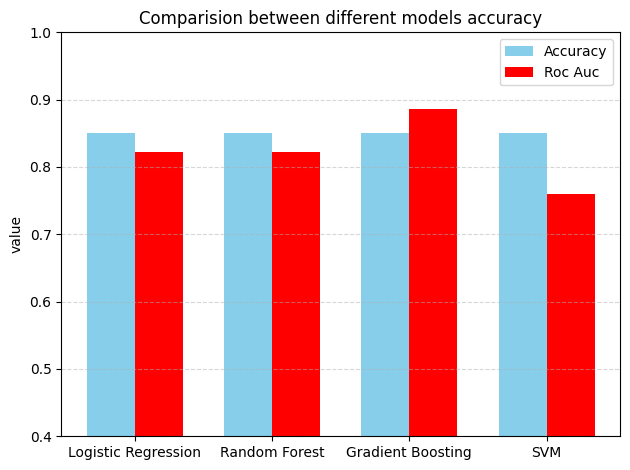

In [44]:
plt.bar(x-width/2, accuracy, width=width, label='Accuracy', color='skyblue')
plt.bar(x+width/2, roc_auc, width=width, label='Roc Auc', color='red')

plt.title('Comparision between different models accuracy')
plt.ylabel('value')
plt.xticks(x, m)
plt.ylim(0.4, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [45]:
gb_model = baseline_models["Gradient Boosting"]

In [46]:
importances = pd.Series(gb_model.feature_importances_, index=X.columns)

In [47]:
importances_sorted = importances.sort_values(ascending=True)

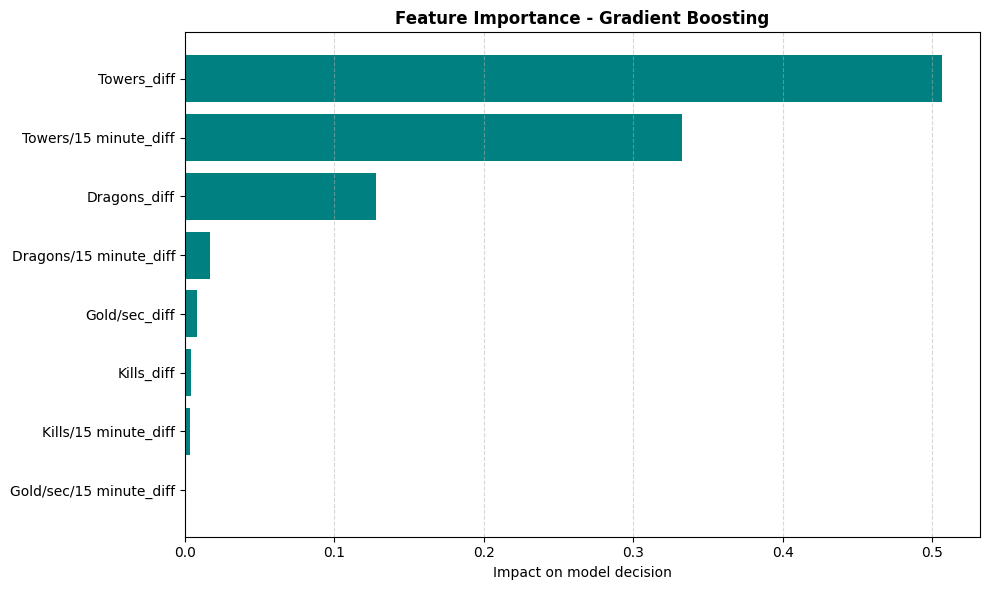

In [48]:
plt.figure(figsize=(10, 6))
plt.barh(importances_sorted.index, importances_sorted.values, color='teal')
plt.title('Feature Importance - Gradient Boosting', fontsize=12, fontweight='bold')
plt.xlabel('Impact on model decision')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 4. Error Analysis & Symmetry Fix, Hyperparameter Tuning (GridSearchCV) and Final Prediction Pipeline

In [49]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
param_grid = {
    'n_estimators': [30, 50, 100],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [2, 3] #hypertuning
}
grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)
tuned_gb_model = grid.best_estimator_
print("Best parameters:", grid.best_params_)

team_a = 'AL'
team_b = 'LNG'

model_to_use = tuned_gb_model

#calculating mean of both positions to match symetry
f_ab = get_match_history(df_all, team_a=team_a, team_b=team_b, N=20).to_frame().T[X.columns].fillna(0)
f_ba = get_match_history(df_all, team_a=team_b, team_b=team_a, N=20).to_frame().T[X.columns].fillna(0)

prob_a_dir1 = model_to_use.predict_proba(scaler.transform(f_ab))[0][1]
prob_b_dir2 = model_to_use.predict_proba(scaler.transform(f_ba))[0][1]

prob_a = ((prob_a_dir1 + (1 - prob_b_dir2)) / 2) * 100
prob_b = 100 - prob_a

print(f"Calculating match odds for: {team_a} vs {team_b}")
print(f"Win chance for {team_a}: {prob_a:.1f}%")
print(f"Win chance for {team_b}: {prob_b:.1f}%")

Best parameters: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 100}
Calculating match odds for: AL vs LNG
Win chance for AL: 70.4%
Win chance for LNG: 29.6%
